In [14]:
%load_ext autoreload
%autoreload 2
import numpy as np
from morphing_birds import Hawk3D, animate, interactive_plot, plot_plotly, plot_multiple



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
hawk3d = Hawk3D("../data/mean_hawk_shape.csv")


In [16]:
hawk3d.current_shape.shape
hawk3d.get_polygon_coords("head").shape

(3, 3)

In [17]:
hawk3d.validate_polygon_shape()

Polygon shape is valid


In [18]:
hawk3d.marker_names

['left_wingtip',
 'right_wingtip',
 'left_primary',
 'right_primary',
 'left_secondary',
 'right_secondary',
 'left_tailtip',
 'right_tailtip']

In [19]:
print(hawk3d.current_shape.shape)
print(hawk3d.default_markers.shape)
print(hawk3d.markers.shape)
print(hawk3d.right_markers.shape)
print(hawk3d.left_markers.shape)


(1, 14, 3)
(1, 8, 3)
(1, 8, 3)
(1, 4, 3)
(1, 4, 3)


In [20]:
hawk3d.skeleton_definition.get_marker_indices(hawk3d.skeleton_definition.marker_names, hawk3d.csv_marker_names)

[1, 12, 2, 11, 0, 13, 5, 6]

In [21]:
hawk3d.skeleton_definition.get_marker_indices(hawk3d.skeleton_definition.fixed_marker_names, hawk3d.csv_marker_names)

[3, 4, 7, 10, 9, 8]

In [22]:
hawk3d.skeleton_definition.fixed_marker_names

['left_shoulder',
 'left_tailbase',
 'right_tailbase',
 'right_shoulder',
 'hood',
 'tailpack']

In [23]:
interactive_plot(hawk3d)

IntSlider(value=60, description='azimuth', max=90, min=-90, step=5)

IntSlider(value=20, description='elevation', max=90, min=-15, step=5)

Output()

In [24]:
# hawk3d.update_keypoints(np.zeros((1,4,3)))

new_hawk = hawk3d
new_hawk.update_keypoints(np.zeros((1,4,3)))
plot_plotly(new_hawk)

In [75]:
hawk3d.restore_keypoints_to_average()
hawk3d.reset_transformation()
hawk3d.transform_keypoints(bodypitch=90, yaw=0)
interactive_plot(hawk3d, az=90, el=0)

IntSlider(value=90, description='azimuth', max=90, min=-90, step=5)

IntSlider(value=0, description='elevation', max=90, min=-15, step=5)

Output()

Figure and axes initialized.


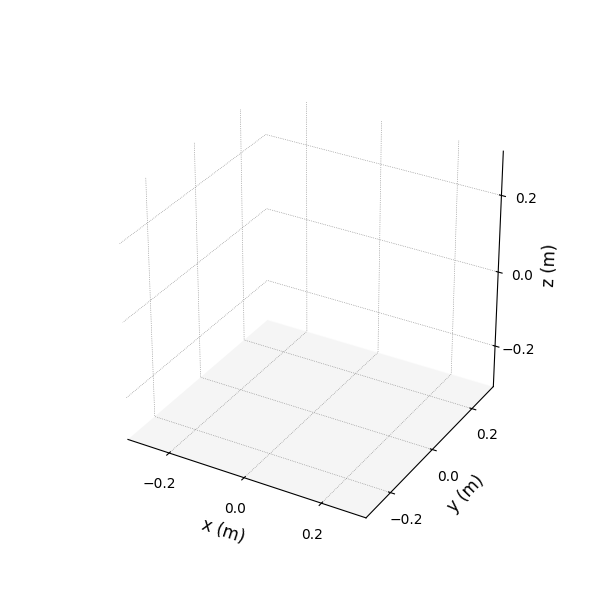

In [76]:
%matplotlib widget
# Make a set of keypoints by adding some random noise to the original keypoints
hawk3d.reset_transformation()
hawk3d.restore_keypoints_to_average()
fake_keypoints = np.random.normal(0, 0.01, (100,8,3)) + hawk3d.markers


# Animate the random motion
animate(hawk3d, fake_keypoints, rotation_type="static")


In [62]:
hawk3d.restore_keypoints_to_average()
hawk3d.reset_transformation()

interactive_plot(hawk3d,az=90, el=0)

IntSlider(value=90, description='azimuth', max=90, min=-90, step=5)

IntSlider(value=0, description='elevation', max=90, min=-15, step=5)

Output()

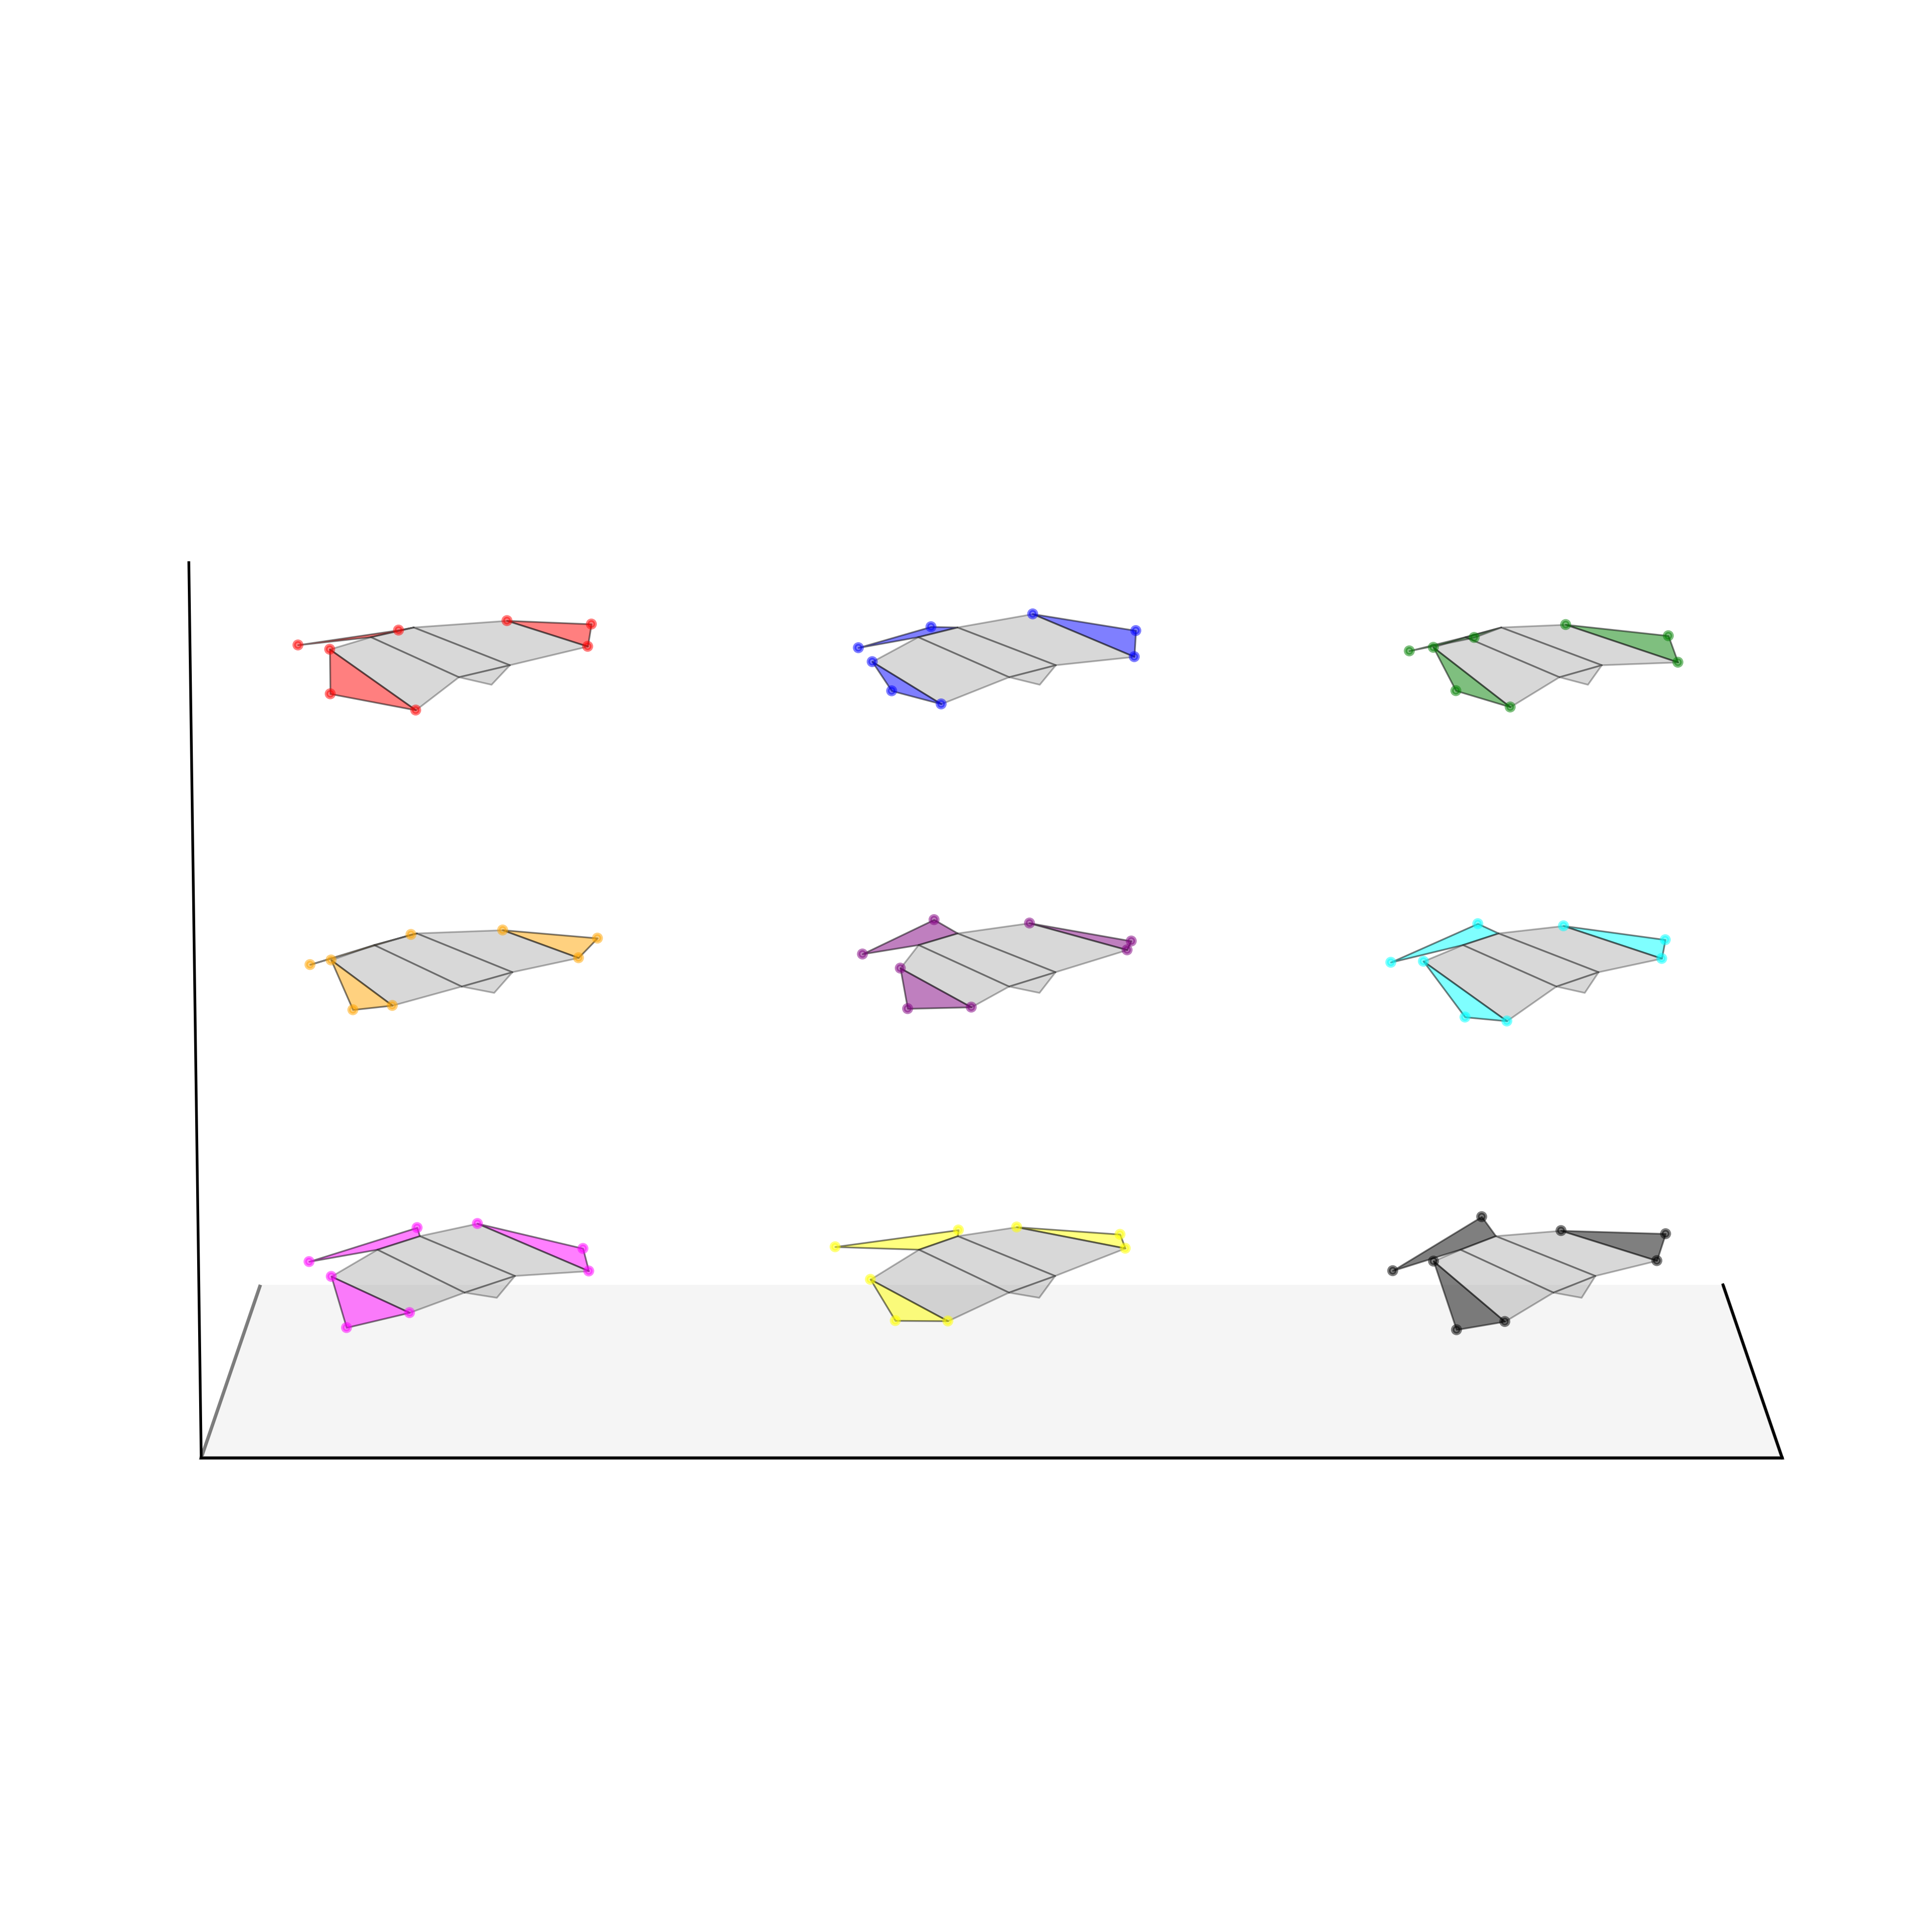

In [67]:

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
hawk3d.restore_keypoints_to_average()
hawk3d.reset_transformation()
colour_list = ["red", "blue", "green", "orange", "purple", "cyan", "magenta", "yellow", "black", "grey", "pink"]
cropped_image = plot_multiple(hawk3d,fake_keypoints, 9, cut_off=0, el=10, rot=-30, colour_list=colour_list)
display(cropped_image)